# 04 · Customer Segmentation (RFM)
**Recency** = days since last order (snapshot 2026-01-01), **Frequency** = distinct orders, **Monetary** = net revenue.
Each is scored 1-5 by quintile (5 = best).

| Segment | Rule (first match wins) |
|---|---|
| New | first order in last 90 days |
| High Value | R≥3, F≥4, M≥4 |
| Loyal | R≥3, F≥3 |
| At Risk | R≤2 and (F≥3 or M≥4) |
| Hibernating | R=1 |
| Occasional | everyone else |

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
MART = "data/processed/mart/"
rfm = pd.read_csv('data/outputs/segmentation/customer_rfm.csv')
rfm.head()

,customer_key,last_order,first_order,frequency,monetary,recency_days,r_score,f_score,m_score,rfm_score,segment
0,1,2024-10-10,2023-02-20,12,"108,780.03",448,2,5,5,255,At Risk
1,2,2024-05-25,2023-03-18,3,"34,890.03",586,1,3,4,134,At Risk
2,3,2023-04-30,2023-01-18,6,"31,672.75",977,1,4,4,144,At Risk
3,4,2023-03-17,2023-03-17,1,"22,408.20",1021,1,1,3,113,Hibernating
4,5,2023-11-13,2023-09-08,4,"13,811.45",780,1,3,2,132,At Risk


In [2]:
rfm[['recency_days','frequency','monetary']].describe(percentiles=[.2,.4,.6,.8]).round(1)

,recency_days,frequency,monetary
count,"8,802.00","8,802.00","8,802.00"
mean,281.30,6.20,"43,785.30"
std,283.50,10.20,"75,634.30"
min,1.00,1.00,135.30
20%,36.00,1.00,"4,442.50"
40%,96.00,2.00,"13,912.40"
60%,271.00,4.00,"29,493.40"
80%,533.00,8.00,"61,617.40"
max,"1,096.00",353.00,"2,202,343.20"


In [3]:
seg = pd.read_csv('data/outputs/segmentation/segment_summary.csv')
seg

,segment,customers,avg_recency_days,avg_orders,avg_revenue,total_revenue,customer_share_pct,revenue_share_pct
0,High Value,1953,68.65,14.87,"111,506.71","217,772,611.42",22.19,56.51
1,At Risk,1943,567.59,7.78,"53,792.92","104,519,635.74",22.07,27.12
2,Loyal,1240,93.36,4.01,"22,658.93","28,097,069.74",14.09,7.29
3,Occasional,1895,248.28,1.46,"9,795.25","18,561,991.47",21.53,4.82
4,New,977,36.26,1.56,"11,073.44","10,818,750.05",11.10,2.81
5,Hibernating,794,777.47,1.38,"7,087.86","5,627,760.28",9.02,1.46


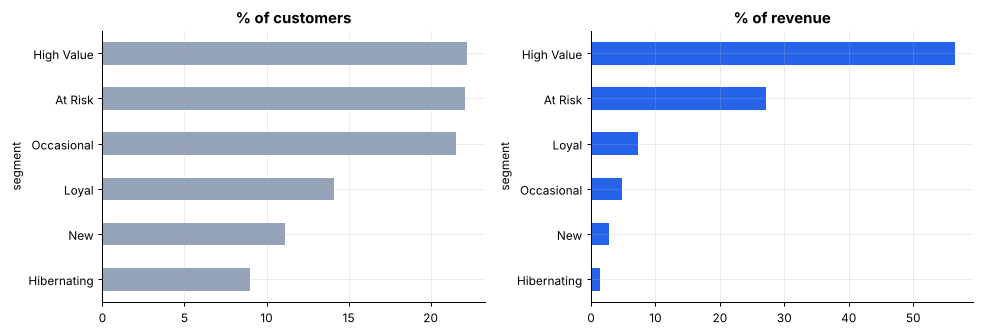

In [4]:
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
seg.set_index('segment')['customer_share_pct'].sort_values().plot.barh(ax=ax[0], color='#94A3B8', title='% of customers')
seg.set_index('segment')['revenue_share_pct'].sort_values().plot.barh(ax=ax[1], color='#2563EB', title='% of revenue')
plt.tight_layout(); plt.show()

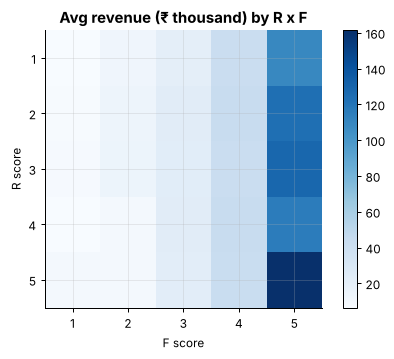

In [5]:
heat = rfm.pivot_table(index='r_score', columns='f_score', values='monetary', aggfunc='mean')/1e3
fig, ax = plt.subplots(figsize=(6,4)); im = ax.imshow(heat.values, cmap='Blues')
ax.set_xticks(range(5), heat.columns); ax.set_yticks(range(5), heat.index); ax.set_xlabel('F score'); ax.set_ylabel('R score')
ax.set_title('Avg revenue (₹ thousand) by R x F'); fig.colorbar(im); plt.show()

**How to use the segments:** protect *High Value* (service priority), grow *Loyal*, run win-back for *At Risk* (largest recoverable revenue), onboard *New*, and keep *Hibernating* on low-cost channels. Every campaign should be measured against a random hold-out group.